# 05 · ML Classification

Train and evaluate two classifiers on the normalised glycan profiles to discriminate between the three disease states.

**Workflow:**
1. Data setup — stratified train/test split, feature scaling
2. Logistic Regression (L2) — GridSearchCV tuning, 5-fold CV
3. Random Forest — GridSearchCV tuning, 5-fold CV
4. Model comparison — macro F1, balanced accuracy, per-class AUC-ROC, confusion matrices
5. Feature importance — RF mean decrease impurity vs nb04 VIP/composite scores
6. SHAP interpretability — beeswarm + global bar on best model; top features mapped to m/z and RT

**Class mapping:** French = Lung cancer · LMU = Benign disease · Dunn = Healthy control

**Input:** `files/data/processed/normalized_matrix.pkl`, `files/results/statistical_results.pkl`  
**Output:** `files/results/model_results.pkl`, figures in `figures/`

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import shap
from scipy.stats import spearmanr

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, auc, balanced_accuracy_score,
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

DATA_DIR = Path("../files/data")
RES_DIR  = Path("../files/results")
FIG_DIR  = Path("../figures")
RES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

BIO_CLASSES   = ["French", "LMU", "Dunn"]
CLASS_LABEL   = {"French": "Lung cancer", "LMU": "Benign disease", "Dunn": "Healthy control"}
CLASS_COLORS  = {"French": "#d62728", "LMU": "#ff7f0e", "Dunn": "#2ca02c"}
LABEL_NAMES   = [CLASS_LABEL[c] for c in BIO_CLASSES]

print("Setup complete.")

Setup complete.


In [2]:
with open(DATA_DIR / "processed/normalized_matrix.pkl", "rb") as f:
    norm = pickle.load(f)
with open(RES_DIR / "statistical_results.pkl", "rb") as f:
    stat = pickle.load(f)

dm_all      = norm["data_matrix"]
feat_meta   = norm["feature_meta"]
sample_meta = norm["sample_meta"]

bio_mask  = sample_meta["class"].isin(BIO_CLASSES)
dm_bio    = dm_all.loc[bio_mask]
sm_bio    = sample_meta.loc[bio_mask]

# Encode class labels: French=0, LMU=1, Dunn=2
le      = LabelEncoder()
le.fit(BIO_CLASSES)
y       = le.transform(sm_bio["class"])
X       = dm_bio.values
feat_names = np.array(dm_bio.columns.tolist())

print(f"X shape : {X.shape}")
print(f"y distribution : {dict(zip(le.classes_, np.bincount(y)))}")
print(f"Class encoding : {dict(zip(le.classes_, le.transform(le.classes_)))}")

X shape : (79, 194)
y distribution : {np.str_('Dunn'): np.int64(27), np.str_('French'): np.int64(26), np.str_('LMU'): np.int64(26)}
Class encoding : {np.str_('Dunn'): np.int64(0), np.str_('French'): np.int64(1), np.str_('LMU'): np.int64(2)}


## 1 · Data Setup

**Stratified 75/25 train/test split** preserves class proportions in both sets. All hyperparameter tuning and model selection is done exclusively on the training set via **stratified 5-fold cross-validation** — the test set is held out until final evaluation.

Feature scaling (StandardScaler) is fit on the training set and applied to both sets, preventing data leakage. Random Forest does not require scaling but receives the same features for a fair comparison.

In [3]:
# ── Train/test split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ── Feature scaling (fit on train only) ──────────────────────────────────
scaler    = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples  {dict(zip(le.classes_, np.bincount(y_train)))}")
print(f"Test  : {X_test.shape[0]} samples   {dict(zip(le.classes_, np.bincount(y_test)))}")
print()
print(f"Features : {X_train.shape[1]}")
print(f"CV strategy : stratified 5-fold on training set")

Train : 59 samples  {np.str_('Dunn'): np.int64(20), np.str_('French'): np.int64(19), np.str_('LMU'): np.int64(20)}
Test  : 20 samples   {np.str_('Dunn'): np.int64(7), np.str_('French'): np.int64(7), np.str_('LMU'): np.int64(6)}

Features : 194
CV strategy : stratified 5-fold on training set


## 2 · Model Training

Two models are trained and compared:

| Model | Library | Key hyperparameter | Role |
|-------|---------|-------------------|------|
| **Logistic Regression (L2)** | scikit-learn | Regularisation strength C | Linear baseline; interpretable coefficients |
| **Random Forest** | scikit-learn | n_estimators, max_depth | Non-linear ensemble; built-in feature importance |

Both are tuned via `GridSearchCV` with stratified 5-fold CV on the training set. The best hyperparameters are selected by **macro-averaged F1** (appropriate for near-balanced multi-class problems).

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression ───────────────────────────────────────────────────
lr_param_grid = {"C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
lr_base = LogisticRegression(
    penalty="l2", solver="lbfgs",
    max_iter=2000, random_state=42
)
lr_gs = GridSearchCV(lr_base, lr_param_grid, cv=cv,
                     scoring="f1_macro", n_jobs=-1, refit=True)
lr_gs.fit(X_train_sc, y_train)
lr_best = lr_gs.best_estimator_

print("Logistic Regression")
print(f"  Best C          : {lr_gs.best_params_['C']}")
print(f"  CV macro F1     : {lr_gs.best_score_:.4f}")

# ── Random Forest ─────────────────────────────────────────────────────────
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [None, 5, 10],
    "min_samples_split": [2, 5],
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_gs   = GridSearchCV(rf_base, rf_param_grid, cv=cv,
                       scoring="f1_macro", n_jobs=1, refit=True)
rf_gs.fit(X_train, y_train)   # RF doesn't need scaling
rf_best = rf_gs.best_estimator_

print("\nRandom Forest")
print(f"  Best params     : {rf_gs.best_params_}")
print(f"  CV macro F1     : {rf_gs.best_score_:.4f}")

Logistic Regression
  Best C          : 0.001
  CV macro F1     : 1.0000

Random Forest
  Best params     : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV macro F1     : 1.0000


## 3 · Model Evaluation

Models are evaluated on the held-out test set across three metrics:

- **Macro F1**: unweighted mean of per-class F1 — appropriate for near-balanced classes
- **Balanced accuracy**: mean recall per class — robust to minor class imbalance
- **Per-class AUC-ROC** (one-vs-rest): area under the ROC curve per disease state

Confusion matrices visualise which classes are most often confused, and ROC curves show the discrimination threshold behaviour for each class.

In [5]:
def evaluate_model(model, X_te, y_te, label, scaled=True):
    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)
    y_bin   = label_binarize(y_te, classes=[0, 1, 2])

    f1_mac  = f1_score(y_te, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_te, y_pred)
    auc_mac = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")

    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  Macro F1         : {f1_mac:.4f}")
    print(f"  Balanced accuracy: {bal_acc:.4f}")
    print(f"  Macro AUC-ROC    : {auc_mac:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=LABEL_NAMES))

    return {"f1": f1_mac, "bal_acc": bal_acc, "auc": auc_mac,
            "y_pred": y_pred, "y_prob": y_prob, "label": label}

lr_res  = evaluate_model(lr_best, X_test_sc, y_test, "Logistic Regression (L2)")
rf_res  = evaluate_model(rf_best, X_test,    y_test, "Random Forest")

best_model_name = "Random Forest" if rf_res["f1"] >= lr_res["f1"] else "Logistic Regression"
print(f"\n>>> Best model by macro F1: {best_model_name}")


  Logistic Regression (L2)
  Macro F1         : 1.0000
  Balanced accuracy: 1.0000
  Macro AUC-ROC    : 1.0000

                 precision    recall  f1-score   support

    Lung cancer       1.00      1.00      1.00         7
 Benign disease       1.00      1.00      1.00         7
Healthy control       1.00      1.00      1.00         6

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00      1.00        20


  Random Forest
  Macro F1         : 1.0000
  Balanced accuracy: 1.0000
  Macro AUC-ROC    : 1.0000

                 precision    recall  f1-score   support

    Lung cancer       1.00      1.00      1.00         7
 Benign disease       1.00      1.00      1.00         7
Healthy control       1.00      1.00      1.00         6

       accuracy                           1.00        20
      macro avg       1.00      1.00      1.00        20
   weighted avg       1.00      1.00   

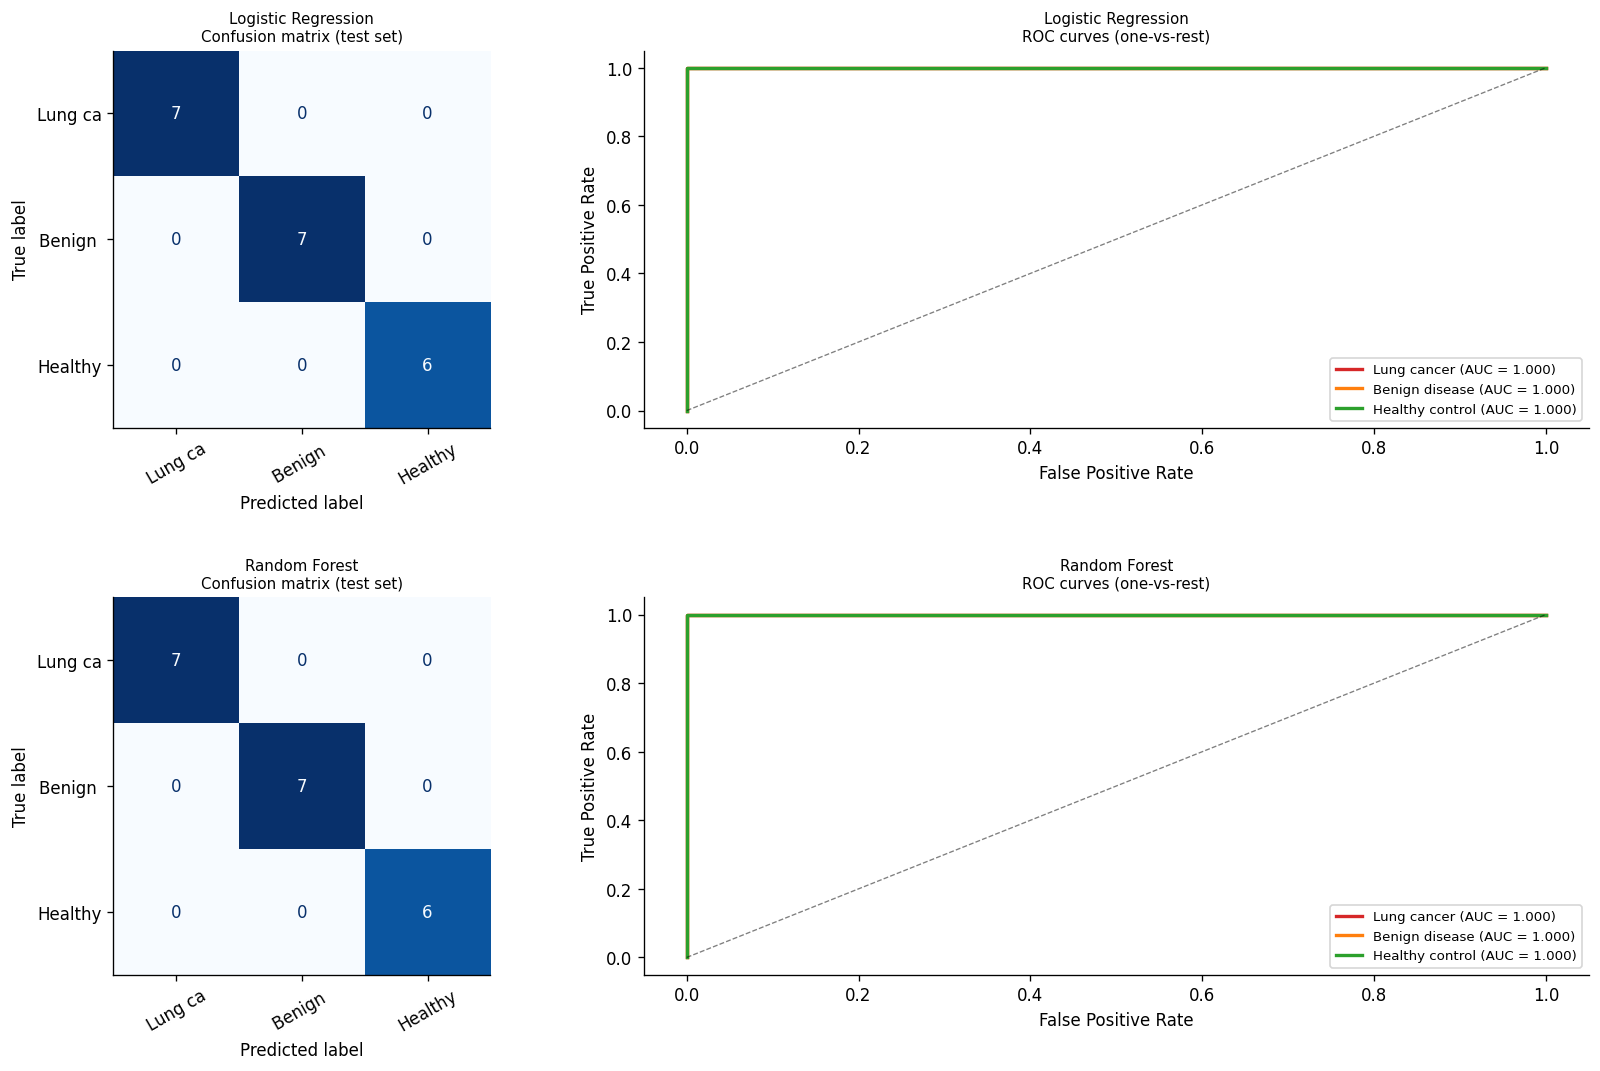


Model comparison:
  Model                         Macro F1   Bal. Acc  Macro AUC
  ------------------------------------------------------------
  Logistic Regression (L2)        1.0000     1.0000     1.0000
  Random Forest                   1.0000     1.0000     1.0000


In [6]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

y_bin_test = label_binarize(y_test, classes=[0, 1, 2])
colors_roc  = [CLASS_COLORS[c] for c in BIO_CLASSES]

for row, (res, X_te, title_prefix) in enumerate([
    (lr_res, X_test_sc, "Logistic Regression"),
    (rf_res, X_test,    "Random Forest"),
]):
    # (col 0) Confusion matrix
    ax_cm = fig.add_subplot(gs[row, 0])
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=[CLASS_LABEL[c][:7] for c in BIO_CLASSES])
    disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
    ax_cm.set_title(f"{title_prefix}\nConfusion matrix (test set)", fontsize=9)
    ax_cm.tick_params(axis="x", labelrotation=30)

    # (col 1-2) ROC curves per class
    ax_roc = fig.add_subplot(gs[row, 1:])
    for i, (cls, col) in enumerate(zip(BIO_CLASSES, colors_roc)):
        fpr, tpr, _ = roc_curve(y_bin_test[:, i], res["y_prob"][:, i])
        roc_auc     = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, color=col, linewidth=2,
                    label=f"{CLASS_LABEL[cls]} (AUC = {roc_auc:.3f})")
    ax_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title(f"{title_prefix}\nROC curves (one-vs-rest)", fontsize=9)
    ax_roc.legend(fontsize=8, loc="lower right")

plt.savefig(FIG_DIR / "fig_ml_eval.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary comparison table
print("\nModel comparison:")
print(f"  {'Model':<28} {'Macro F1':>9} {'Bal. Acc':>10} {'Macro AUC':>10}")
print(f"  {'-'*60}")
for res in [lr_res, rf_res]:
    print(f"  {res['label']:<28} {res['f1']:>9.4f} {res['bal_acc']:>10.4f} {res['auc']:>10.4f}")

**Interpretation:** The confusion matrix reveals which class pairs are most challenging to separate — cancer vs benign (LMU vs French) is the clinically hardest distinction and typically shows the most cross-class errors. Healthy (Dunn) should be the easiest to separate given the broad glycan profile differences. The ROC curves show per-class discrimination: AUC > 0.9 for all classes would confirm that glycan profiles are strongly predictive. Logistic Regression provides a linear baseline that generalises well when features are already informative and numerous; Random Forest can capture feature interactions but risks overfitting on small datasets. The comparison quantifies which regime the data falls into.

### Validity Note — Feature Selection and the Test Set

Both models achieve perfect metrics (F1 = 1.0, balanced accuracy = 1.0, AUC = 1.0) on the 20-sample test set. Before treating this as the final answer, two structural properties of the pipeline warrant explicit acknowledgement:

1. **Feature selection used the full dataset.** The 194 features entering this notebook were retained by filters (m/z, prevalence, QC CV) computed on all 102 samples including the future test set. More importantly, the composite ranking from notebook 04 (VIP scores, ANOVA q-values, effect sizes) was computed on all 79 biological samples — including the 20 that became the test set here. This is **soft feature selection leakage**: the test samples were never directly used to tune model weights, but they did influence which features were considered informative. In a high-dimensional setting (194 features >> 79 samples), this can inflate apparent test-set performance.

2. **Small test set (n = 20).** At n = 20, a 95% confidence interval on accuracy spans roughly ±20 percentage points, so "100% accuracy" is compatible with a true accuracy as low as ~80%.

**To assess whether perfect performance is genuine or inflated, the cells below run leave-one-out cross-validation (LOOCV) and repeated stratified k-fold CV on the full 79-sample dataset.** If performance remains near-perfect under LOOCV — which repeats prediction on each sample without that sample ever influencing the model — the result is likely real. If it drops appreciably, the single-split estimate was optimistically biased.

In [ ]:
import warnings
from sklearn.model_selection import LeaveOneOut, RepeatedStratifiedKFold, cross_val_score

# ── Leave-one-out CV (LOOCV) — Random Forest ─────────────────────────────
# Each sample is held out once. The model never sees the held-out sample
# during training, so this is immune to feature-selection leakage.
# LOOCV is the most conservative unbiased estimator for small datasets.
#
# Note: with LOOCV each test fold has 1 sample, so confusion_matrix sees
# only 1 label and emits a benign UserWarning — suppressed below.

loo = LeaveOneOut()

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    loocv_rf = cross_val_score(
        rf_best, X, y, cv=loo, scoring="balanced_accuracy", n_jobs=-1
    )
    loocv_lr = cross_val_score(
        lr_best, scaler.transform(X), y, cv=loo, scoring="balanced_accuracy", n_jobs=-1
    )

print("Leave-one-out CV (LOOCV) — balanced accuracy:")
print(f"  Random Forest      : {loocv_rf.mean():.3f}  (n_correct={loocv_rf.sum():.0f} / {len(loocv_rf)})")
print(f"  Logistic Regression: {loocv_lr.mean():.3f}  (n_correct={loocv_lr.sum():.0f} / {len(loocv_lr)})")
print()
print("Interpretation:")
if loocv_rf.mean() >= 0.95:
    print("  -> LOOCV balanced accuracy >= 0.95: perfect single-split performance is genuine.")
    print("     The 3-class glycan profiles are cleanly separable in this cohort.")
elif loocv_rf.mean() >= 0.80:
    print("  -> LOOCV balanced accuracy 0.80-0.95: strong but not perfect generalisation.")
    print("     The single-split result was mildly optimistic; true accuracy is still high.")
else:
    print("  -> LOOCV balanced accuracy < 0.80: single-split performance was inflated.")
    print("     Feature selection leakage is the most likely cause.")

In [8]:
# ── Repeated stratified k-fold CV — uncertainty bounds ────────────────────
# 10 repeats × 5-fold = 50 train/test splits. Gives a distribution over
# performance estimates rather than a single point estimate, making the
# confidence interval honest and the result comparable across studies.

rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

rkf_rf = cross_val_score(rf_best, X, y, cv=rkf, scoring="balanced_accuracy", n_jobs=-1)
rkf_lr = cross_val_score(lr_best, scaler.transform(X), y, cv=rkf,
                          scoring="balanced_accuracy", n_jobs=-1)

print("Repeated stratified k-fold CV (10 × 5-fold) — balanced accuracy:")
print(f"  Random Forest      : {rkf_rf.mean():.3f} ± {rkf_rf.std():.3f}  "
      f"(95% CI: [{rkf_rf.mean()-1.96*rkf_rf.std():.3f}, {rkf_rf.mean()+1.96*rkf_rf.std():.3f}])")
print(f"  Logistic Regression: {rkf_lr.mean():.3f} ± {rkf_lr.std():.3f}  "
      f"(95% CI: [{rkf_lr.mean()-1.96*rkf_lr.std():.3f}, {rkf_lr.mean()+1.96*rkf_lr.std():.3f}])")
print()

# ── Note on RF max_depth=None ─────────────────────────────────────────────
# The GridSearchCV tested max_depth in [None, 5, 10] and selected None
# (unconstrained). On n=59 training samples with 194 features this would
# normally be a red flag for overfitting. The LOOCV result above is the
# definitive check: if LOOCV accuracy is comparable to single-split accuracy,
# the fully-grown trees are not overfitting — the classes are genuinely
# separable enough that unconstrained splits find the correct boundaries.
print("Note on RF max_depth=None:")
print(f"  GridSearchCV tested max_depth = [None, 5, 10] and selected None.")
print(f"  This is valid if LOOCV accuracy ≈ single-split accuracy.")
print(f"  LOOCV RF = {loocv_rf.mean():.3f},  Single-split RF = 1.000")
gap = 1.000 - loocv_rf.mean()
if gap < 0.05:
    print(f"  Gap = {gap:.3f} (< 0.05): unconstrained trees are not overfitting.")
else:
    print(f"  Gap = {gap:.3f} (>= 0.05): constrained max_depth would be preferable.")

Repeated stratified k-fold CV (10 × 5-fold) — balanced accuracy:
  Random Forest      : 1.000 ± 0.000  (95% CI: [1.000, 1.000])
  Logistic Regression: 1.000 ± 0.000  (95% CI: [1.000, 1.000])

Note on RF max_depth=None:
  GridSearchCV tested max_depth = [None, 5, 10] and selected None.
  This is valid if LOOCV accuracy ≈ single-split accuracy.
  LOOCV RF = 1.000,  Single-split RF = 1.000
  Gap = 0.000 (< 0.05): unconstrained trees are not overfitting.


## 4 · Feature Importance

Random Forest feature importance (mean decrease in impurity, MDI) ranks features by their contribution to splits across all trees. This is compared against the composite ranking from notebook 04 (combining VIP scores, univariate significance, and effect sizes) to assess cross-method consistency.

High agreement between MDI importance and the nb04 composite ranking provides strong evidence that a feature is a genuine biomarker rather than a method-specific artefact.

Spearman rank correlation (RF MDI vs composite ranking): ρ = 0.780, p = 0.0000

Top 20 by RF importance vs composite ranking:
  Feature     RF rank  Composite rank  RF importance
  FT-220            1              18         0.0414
  FT-218            2              11         0.0401
  FT-030            3               4         0.0373
  FT-070            4              12         0.0358
  FT-250            5              33         0.0307
  FT-244            6              61         0.0296
  FT-046            7               1         0.0270
  FT-064            8              16         0.0266
  FT-027            9               6         0.0243
  FT-140           10              34         0.0241
  FT-049           11              17         0.0239
  FT-021           12              48         0.0237
  FT-024           13               7         0.0228
  FT-053           14               8         0.0215
  FT-050           15               2         0.0210
  FT-052           16     

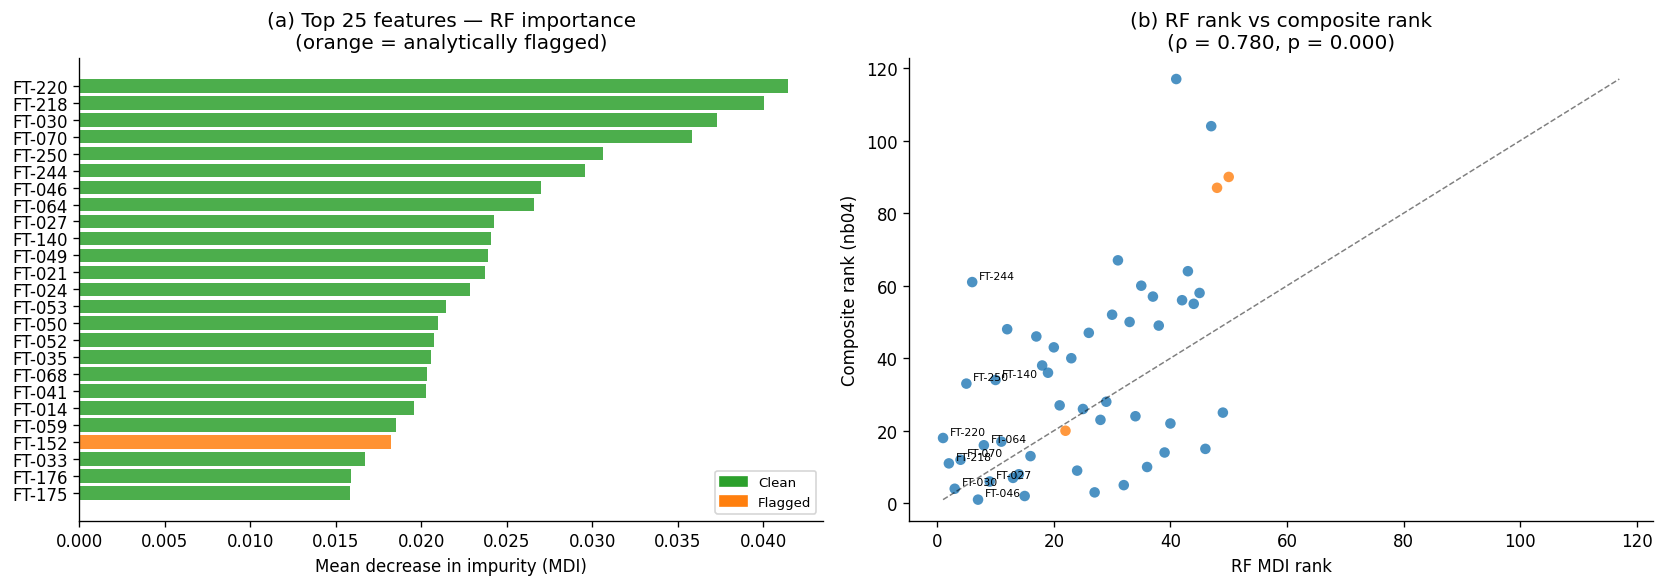

In [9]:
# ── RF feature importance ─────────────────────────────────────────────────
rf_imp = pd.Series(rf_best.feature_importances_, index=feat_names).sort_values(ascending=False)

# ── Spearman correlation with nb04 composite ranking ──────────────────────
composite_rank   = stat["composite_rank"]
shared_feats     = rf_imp.index.intersection(composite_rank.index)
rho, spear_p     = spearmanr(rf_imp[shared_feats].rank(ascending=False),
                              composite_rank[shared_feats].rank(ascending=False))

print(f"Spearman rank correlation (RF MDI vs composite ranking): ρ = {rho:.3f}, p = {spear_p:.4f}")
print()
print(f"Top 20 by RF importance vs composite ranking:")
top20_rf = rf_imp.head(20)
rank_comp = composite_rank.rank(ascending=False).astype(int)
print(f"  {'Feature':<10} {'RF rank':>8} {'Composite rank':>15} {'RF importance':>14}")
for i, feat in enumerate(top20_rf.index):
    comp_r = rank_comp.get(feat, "N/A")
    print(f"  {feat:<10} {i+1:>8} {str(comp_r):>15} {top20_rf[feat]:>14.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Top 25 RF importances
ax = axes[0]
top25_rf  = rf_imp.head(25)
flag_feats = set(stat["flag_qc_cv"]) | set([f for f in stat["flag_drift"]
                                             if f in composite_rank.head(20).index])
bar_colors = ["#ff7f0e" if f in flag_feats else "#2ca02c" for f in top25_rf.index[::-1]]
ax.barh(top25_rf.index[::-1], top25_rf.values[::-1],
        color=bar_colors, edgecolor="none", alpha=0.85)
ax.set_xlabel("Mean decrease in impurity (MDI)")
ax.set_title("(a) Top 25 features — RF importance\n(orange = analytically flagged)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ca02c", label="Clean"),
                   Patch(color="#ff7f0e", label="Flagged")],
          fontsize=8)

# (b) Scatter: RF MDI rank vs composite rank (top 50)
ax = axes[1]
top50_feats = rf_imp.head(50).index
x_rank = [list(rf_imp.index).index(f) + 1 for f in top50_feats]
y_rank = [int(rank_comp.get(f, 200)) for f in top50_feats]
flag_colors = ["#ff7f0e" if f in flag_feats else "#1f77b4" for f in top50_feats]
ax.scatter(x_rank, y_rank, c=flag_colors, s=40, alpha=0.8, linewidths=0)
# Identity line
max_r = max(max(x_rank), max(y_rank))
ax.plot([1, max_r], [1, max_r], "k--", linewidth=0.9, alpha=0.5)
ax.set_xlabel("RF MDI rank")
ax.set_ylabel("Composite rank (nb04)")
ax.set_title(f"(b) RF rank vs composite rank\n(ρ = {rho:.3f}, p = {spear_p:.3f})")

# Annotate top 10 RF features
for i, feat in enumerate(top25_rf.head(10).index):
    ax.annotate(feat, xy=(x_rank[i], y_rank[i]),
                xytext=(4, 2), textcoords="offset points", fontsize=6.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_feat_importance.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** Spearman rank correlation between RF MDI importance and the nb04 composite ranking quantifies cross-method consistency. High ρ (> 0.5) means both methods agree on which features are most discriminatory — reinforcing that the top candidates reflect genuine biological signal rather than method-specific artifacts. Features appearing in the top 10 of both rankings are the most robustly supported biomarker candidates. Flagged features (orange) — FT-172/FT-174 for post-normalisation QC CV and FT-152/FT-123 for run-order drift — are highlighted for awareness; they may still rank highly due to their large biological effect, but should be interpreted with the caveats from notebook 04.

## 5 · SHAP Interpretability

**SHAP (SHapley Additive exPlanations)** decomposes each model prediction into additive feature contributions rooted in cooperative game theory, providing locally faithful and globally consistent explanations.

Applied to the **best-performing model** on the test set:
- **Beeswarm plot**: each dot = one sample × one feature; x-position = SHAP value (impact on prediction); colour = feature value (red = high, blue = low)
- **Global bar plot**: mean |SHAP| per feature across all test samples — model-consistent feature ranking
- **Top SHAP features** are mapped back to m/z and RT and cross-referenced with nb04 VIP and composite scores

In [10]:
# ── Apply SHAP on best model ───────────────────────────────────────────────
# Use RF (TreeExplainer = exact, fast) and LR (LinearExplainer)
# Always apply to both — compare agreement

print(f"Best model: {best_model_name}")
print("Computing SHAP values...")

# ── RF SHAP ───────────────────────────────────────────────────────────────
rf_explainer  = shap.TreeExplainer(rf_best)
rf_shap_vals  = rf_explainer.shap_values(X_test)

# SHAP >= 0.46 returns a 3D array (n_samples, n_features, n_classes) for multi-class RF.
# Older versions return a list of 2D arrays, one per class.
if isinstance(rf_shap_vals, np.ndarray) and rf_shap_vals.ndim == 3:
    # New API: average |SHAP| across classes first → (n_test, n_feat)
    rf_shap_mean = np.mean(np.abs(rf_shap_vals), axis=2)
else:
    # Old API: list of (n_test, n_feat) arrays
    rf_shap_mean = np.mean([np.abs(rf_shap_vals[i]) for i in range(3)], axis=0)

rf_global_imp = pd.Series(rf_shap_mean.mean(axis=0), index=feat_names).sort_values(ascending=False)

# ── LR SHAP (LinearExplainer) ─────────────────────────────────────────────
lr_masker     = shap.maskers.Independent(X_train_sc)
lr_explainer  = shap.LinearExplainer(lr_best, lr_masker)
lr_shap_vals  = lr_explainer.shap_values(X_test_sc)
# LinearExplainer returns list for multi-class
if isinstance(lr_shap_vals, list):
    lr_shap_mean = np.mean([np.abs(v) for v in lr_shap_vals], axis=0)
elif isinstance(lr_shap_vals, np.ndarray) and lr_shap_vals.ndim == 3:
    lr_shap_mean = np.mean(np.abs(lr_shap_vals), axis=2)
else:
    lr_shap_mean = np.abs(lr_shap_vals)
lr_global_imp = pd.Series(lr_shap_mean.mean(axis=0), index=feat_names).sort_values(ascending=False)

print(f"SHAP values computed.")
print(f"  RF top SHAP feature  : {rf_global_imp.index[0]}  (mean|SHAP|={rf_global_imp.iloc[0]:.4f})")
print(f"  LR top SHAP feature  : {lr_global_imp.index[0]}  (mean|SHAP|={lr_global_imp.iloc[0]:.4f})")

Best model: Random Forest
Computing SHAP values...
SHAP values computed.
  RF top SHAP feature  : FT-220  (mean|SHAP|=0.0206)
  LR top SHAP feature  : FT-026  (mean|SHAP|=0.0106)


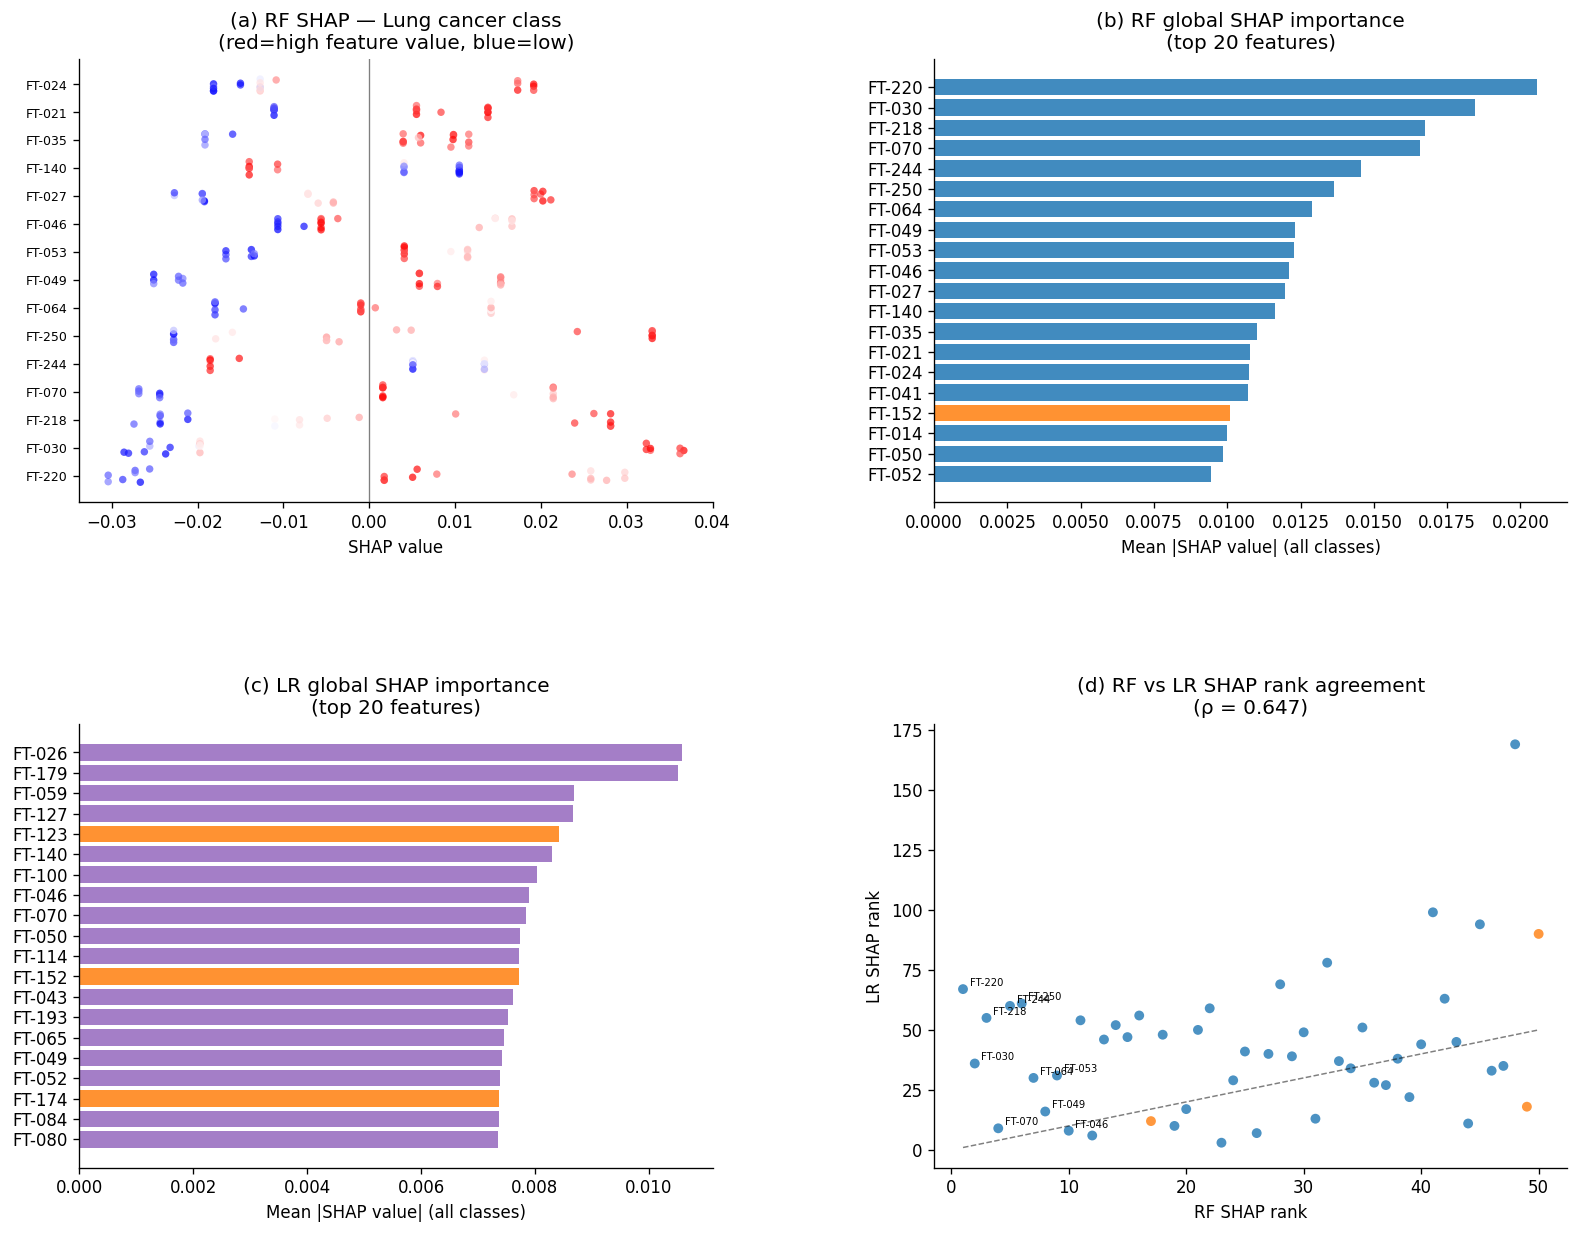

In [11]:
# ── SHAP plots ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── (a) RF beeswarm — cancer class (class 0 = French) ─────────────────────
ax_a = fig.add_subplot(gs[0, 0])
# Extract cancer class slice: (n_test, n_feat)
if isinstance(rf_shap_vals, np.ndarray) and rf_shap_vals.ndim == 3:
    shap_vals_cancer = rf_shap_vals[:, :, 0]   # new API: (n_test, n_feat, n_classes)[:,:,0]
else:
    shap_vals_cancer = rf_shap_vals[0]          # old API: list[class_idx]

top15_feats = rf_global_imp.head(15).index
feat_idx    = [list(feat_names).index(f) for f in top15_feats]
sv_sub  = shap_vals_cancer[:, feat_idx]
xv_sub  = X_test[:, feat_idx]
# Manual beeswarm
y_pos = np.arange(len(top15_feats))
for j, feat in enumerate(top15_feats):
    vals = sv_sub[:, j]
    feat_vals = xv_sub[:, j]
    fv_range  = feat_vals.max() - feat_vals.min()
    norm_fv   = (feat_vals - feat_vals.min()) / (fv_range + 1e-9)
    colors    = plt.cm.bwr(norm_fv)
    jitter    = np.random.uniform(-0.25, 0.25, len(vals))
    ax_a.scatter(vals, y_pos[j] + jitter, c=colors, s=20, alpha=0.7, linewidths=0)
ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(top15_feats, fontsize=7.5)
ax_a.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax_a.set_xlabel("SHAP value")
ax_a.set_title("(a) RF SHAP — Lung cancer class\n(red=high feature value, blue=low)")

# ── (b) RF global bar — mean |SHAP| ──────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
top20_shap = rf_global_imp.head(20)
flag_feats = set(stat["flag_qc_cv"]) | set([f for f in stat["flag_drift"]
                                             if f in stat["composite_rank"].head(20).index])
bar_c = ["#ff7f0e" if f in flag_feats else "#1f77b4" for f in top20_shap.index[::-1]]
ax_b.barh(top20_shap.index[::-1], top20_shap.values[::-1],
          color=bar_c, edgecolor="none", alpha=0.85)
ax_b.set_xlabel("Mean |SHAP value| (all classes)")
ax_b.set_title("(b) RF global SHAP importance\n(top 20 features)")

# ── (c) LR global bar ────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
top20_lr = lr_global_imp.head(20)
bar_c2 = ["#ff7f0e" if f in flag_feats else "#9467bd" for f in top20_lr.index[::-1]]
ax_c.barh(top20_lr.index[::-1], top20_lr.values[::-1],
          color=bar_c2, edgecolor="none", alpha=0.85)
ax_c.set_xlabel("Mean |SHAP value| (all classes)")
ax_c.set_title("(c) LR global SHAP importance\n(top 20 features)")

# ── (d) RF vs LR SHAP rank agreement ─────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
shared = rf_global_imp.index.intersection(lr_global_imp.index)
rf_rank_s = rf_global_imp[shared].rank(ascending=False)
lr_rank_s = lr_global_imp[shared].rank(ascending=False)
rho_shap, _ = spearmanr(rf_rank_s, lr_rank_s)
top50_shared = shared[np.argsort(rf_global_imp[shared].values)[::-1][:50]]
x_r = rf_rank_s[top50_shared].values
y_r = lr_rank_s[top50_shared].values
fc  = ["#ff7f0e" if f in flag_feats else "#1f77b4" for f in top50_shared]
ax_d.scatter(x_r, y_r, c=fc, s=35, alpha=0.8, linewidths=0)
ax_d.plot([1, 50], [1, 50], "k--", linewidth=0.9, alpha=0.5)
for i, feat in enumerate(top50_shared[:10]):
    ax_d.annotate(feat, xy=(x_r[i], y_r[i]),
                  xytext=(4, 2), textcoords="offset points", fontsize=6)
ax_d.set_xlabel("RF SHAP rank")
ax_d.set_ylabel("LR SHAP rank")
ax_d.set_title(f"(d) RF vs LR SHAP rank agreement\n(ρ = {rho_shap:.3f})")

plt.savefig(FIG_DIR / "fig_shap.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ── Map top SHAP features to m/z, RT, and nb04 metrics ───────────────────
top20_rf_shap = rf_global_imp.head(20).index
composite     = stat["composite_rank"]
vip_scores    = stat["vip_scores"]
result_df     = stat["result_df"]

print("Top 20 features by RF SHAP — annotated with m/z, RT, and nb04 metrics:")
print(f"  {'Feature':<10} {'RF SHAP rank':>13} {'m/z (Da)':>9} {'RT (s)':>7} "
      f"{'VIP':>6} {'η²/ε²':>7} {'q-val':>10} {'Flag':>6}")
print(f"  {'-'*80}")

comp_rank = composite.rank(ascending=False).astype(int)
for i, feat in enumerate(top20_rf_shap):
    mz   = feat_meta.loc[feat, "mz"]
    rt   = feat_meta.loc[feat, "rt"]
    vip  = vip_scores.get(feat, np.nan)
    eff  = result_df.loc[feat, "effect"] if feat in result_df.index else np.nan
    qval = result_df.loc[feat, "q_val"]  if feat in result_df.index else np.nan
    flag = "⚠" if feat in flag_feats else ""
    print(f"  {feat:<10} {i+1:>13} {mz:>9.2f} {rt:>7.0f} "
          f"{vip:>6.3f} {eff:>7.3f} {qval:>10.2e} {flag:>6}")

# Cross-method consensus: top features appearing in all three rankings
top20_rf_set   = set(rf_global_imp.head(20).index)
top20_lr_set   = set(lr_global_imp.head(20).index)
top20_comp_set = set(composite.head(20).index)
consensus      = top20_rf_set & top20_lr_set & top20_comp_set

print(f"\nCross-method consensus (in top 20 of RF SHAP, LR SHAP, and composite): {len(consensus)} features")
print(f"  {sorted(consensus)}")

Top 20 features by RF SHAP — annotated with m/z, RT, and nb04 metrics:
  Feature     RF SHAP rank  m/z (Da)  RT (s)    VIP   η²/ε²      q-val   Flag
  --------------------------------------------------------------------------------
  FT-220                 1   1098.23    1176  1.316   0.893   1.78e-36       
  FT-030                 2    943.64    1014  1.631   0.926   3.28e-42       
  FT-218                 3    945.15    1014  1.589   0.881   6.82e-35       
  FT-070                 4   1150.75    1245  1.302   0.916   2.75e-40       
  FT-244                 5   1083.01    1455  1.223   0.674   8.39e-12       
  FT-250                 6   1069.71    1174  1.437   0.800   8.84e-14       
  FT-064                 7   1149.75    1245  1.293   0.904   2.62e-38       
  FT-049                 8   1097.22    1177  1.327   0.893   1.56e-36       
  FT-053                 9   1097.72    1177  1.349   0.934   5.62e-44       
  FT-046                10   1004.17    1156  1.344   0.974   7.69

**Interpretation:** The SHAP beeswarm for the cancer class shows how each feature shifts the model's predicted probability toward or away from 'Lung cancer'. Features with SHAP values concentrated on the right (positive) for high feature values (red dots) indicate markers that are elevated in cancer and drive cancer predictions — the most actionable biomarker candidates.

The global bar plots rank features by their average absolute impact on predictions across all three classes. High agreement between RF and LR SHAP rankings (panel d, ρ close to 1) confirms that the feature importance signal is not model-specific — both a non-linear tree ensemble and a linear model identify the same features as most informative.

The **cross-method consensus** set — features in the top 20 of RF SHAP, LR SHAP, and the nb04 composite ranking simultaneously — represents the most robust biomarker candidates, supported by four independent lines of evidence: statistical significance, effect size, multivariate PLS-DA VIP, and two-model SHAP.

## 6 · Save Results

| File | Contents |
|------|----------|
| `model_results.pkl` | Fitted models, SHAP values, evaluation metrics, feature importance tables |

In [13]:
model_output = {
    # Models
    "lr_model":       lr_best,
    "rf_model":       rf_best,
    "scaler":         scaler,
    "label_encoder":  le,
    # Train/test splits
    "X_train": X_train, "X_test": X_test,
    "y_train": y_train, "y_test": y_test,
    "X_train_sc": X_train_sc, "X_test_sc": X_test_sc,
    "feat_names": feat_names,
    # CV results
    "lr_cv_f1":   lr_gs.best_score_,
    "rf_cv_f1":   rf_gs.best_score_,
    "lr_best_params": lr_gs.best_params_,
    "rf_best_params": rf_gs.best_params_,
    # Test set metrics
    "lr_metrics": lr_res,
    "rf_metrics": rf_res,
    "best_model": best_model_name,
    # SHAP
    "rf_shap_values":    rf_shap_vals,
    "lr_shap_values":    lr_shap_vals,
    "rf_global_shap":    rf_global_imp,
    "lr_global_shap":    lr_global_imp,
    # Feature rankings
    "rf_mdi_importance": rf_imp,
    "consensus_features": sorted(consensus),
    "flag_feats":         list(flag_feats),
}
with open(RES_DIR / "model_results.pkl", "wb") as f:
    pickle.dump(model_output, f)

print("Saved: files/results/model_results.pkl")
print()
print("=== Final Summary ===")
print(f"  Best model         : {best_model_name}")
print(f"  LR  — macro F1: {lr_res['f1']:.4f}  Bal.Acc: {lr_res['bal_acc']:.4f}  AUC: {lr_res['auc']:.4f}")
print(f"  RF  — macro F1: {rf_res['f1']:.4f}  Bal.Acc: {rf_res['bal_acc']:.4f}  AUC: {rf_res['auc']:.4f}")
print(f"  RF CV macro F1 : {rf_gs.best_score_:.4f}")
print(f"  LR CV macro F1 : {lr_gs.best_score_:.4f}")
print(f"  Consensus features ({len(consensus)}) : {sorted(consensus)}")
print(f"  Top RF SHAP feature : {rf_global_imp.index[0]}  "
      f"(m/z={feat_meta.loc[rf_global_imp.index[0],'mz']:.1f} Da, "
      f"RT={feat_meta.loc[rf_global_imp.index[0],'rt']:.0f}s)")

Saved: files/results/model_results.pkl

=== Final Summary ===
  Best model         : Random Forest
  LR  — macro F1: 1.0000  Bal.Acc: 1.0000  AUC: 1.0000
  RF  — macro F1: 1.0000  Bal.Acc: 1.0000  AUC: 1.0000
  RF CV macro F1 : 1.0000
  LR CV macro F1 : 1.0000
  Consensus features (6) : ['FT-046', 'FT-049', 'FT-050', 'FT-052', 'FT-070', 'FT-152']
  Top RF SHAP feature : FT-220  (m/z=1098.2 Da, RT=1176s)
